
<h2 id="Example-of-Integration-in-TH1-&amp;-TF1">Example of Integration in TH1 &amp; TF1</h2>


In [ ]:
//%jsroot on
auto c1=new TCanvas;


<h3 id="1.Create-Backgrond-and-Signal-Function">1.Create Backgrond and Signal Function</h3>
<p>先画出设定的 signal、本底及总函数。随后 FillRandom 分别按函数形状抽样指定数量的事件；抽样数量由 FillRandom 的第二个参数决定，不等于初始函数的积分。</p>

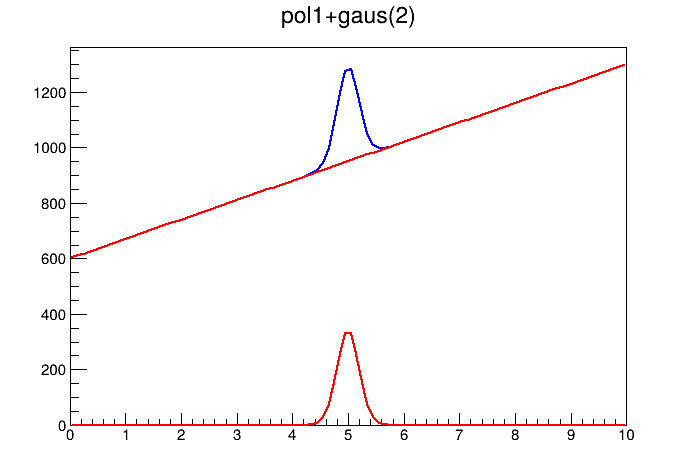

In [4]:
TF1 *fB = new TF1("fB","pol1",0,10);
TF1 *fS = new TF1("fS","gaus",0,10);
TF1 *fSB = new TF1("fSB","pol1+gaus(2)",0,10);
fB->SetParameters(600,70);
fS->SetParameters(340,5,0.2);
fSB->SetParameters(600,70,340,5,0.2);
fSB->SetMinimum(0);
fSB->Draw();
fSB->SetLineColor(kBlue);
fS->Draw("same");
fB->Draw("same");
c1->Draw();


<h3 id="2.Create-Histograms">2.Create Histograms</h3>


In [ ]:
TH1D *hB=new TH1D("hB","hB",100,0,10);
TH1D *hS=new TH1D("hS","hS",100,0,10);
TH1D *hSB=new TH1D("hSB","hSB",100,0,10);
gRandom->SetSeed(1901);
hB->FillRandom("fB",100000);
hS->FillRandom("fS",2000);
hSB->Add(hB,hS,1,1);


<h3 id="3.Separate-Background-&amp;-Signals-by-fitting-Background+Signal-histogram">3.Separate Background &amp; Signals by fitting Background+Signal histogram</h3>


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      26.3039
NDf                       =           25
Edm                       =  3.58116e-06
NCalls                    =          138
p0                        =      550.657   +/-   34.0768
p1                        =      90.4691   +/-   6.79291
p2                        =      374.452   +/-   23.3096
p3                        =      4.99208   +/-   0.0146411
p4                        =     0.214643   +/-   0.0153591

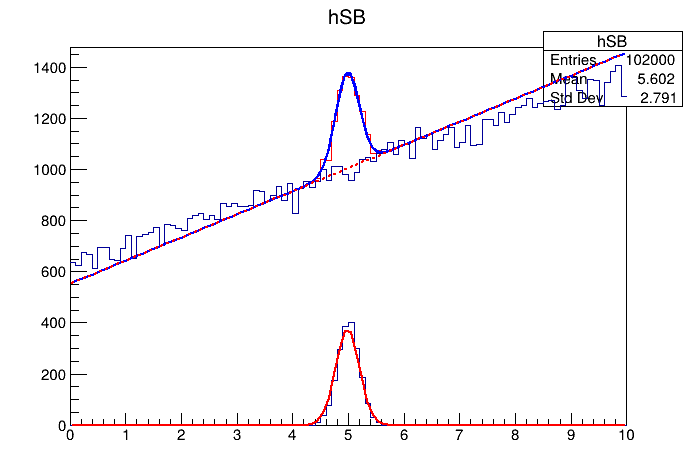

In [8]:
double par[5];
hSB->Fit("fSB","","",3.5,6.5);
fSB->GetParameters(&par[0]);
fB->SetParameters(&par[0]);
fS->SetParameters(&par[2]);
hSB->SetMinimum(0);
hSB->Draw();
hSB->SetLineColor(kRed);
hS->Draw("same");
fS->Draw("same");
hB->Draw("same");
fSB->Draw("same"); // 联合拟合的总函数
fB->SetLineStyle(2);
fB->Draw("same");
c1->Draw();


<h3 id="3.-Calculate-Signal-counts-from-TH1-&amp;-TF1">3. Calculate Signal counts from TH1 &amp; TF1</h3>
<p>下面比较模拟中已知的 signal 计数、拟合 signal 的积分，以及总计数减去拟合本底。后两者是同一数据上的估计，并非独立测量。积分保留 double，避免把拟合值截断为整数。峰面积的误差传播见共用的 <a href="https://zhihuanli.github.io/Experimental-Method-in-Nuclear-Physics/tutorial/ROOT/ROOT_Tutorial_I_CPP.html">ROOT Tutorial I</a>。</p>

In [10]:
double x1=3.6;//x1,x2：Both values must be within the fitting range
double x2=6.3;
int bin1=hSB->FindBin(x1);
int bin2=hSB->FindBin(x2);
double nhSB=hSB->Integral(bin1,bin2);
double nhB=hB->Integral(bin1,bin2);
double nhS=hS->Integral(bin1,bin2);
double fx1=hSB->GetBinLowEdge(bin1);
double fx2=hSB->GetBinLowEdge(bin2)+hSB->GetBinWidth(bin2);
cout<<bin1<<" "<<bin2<<endl;
double nfB=fB->Integral(fx1,fx2)/hSB->GetBinWidth(bin2);
double nfS=fS->Integral(fx1,fx2)/hSB->GetBinWidth(bin2);
double nfSB=fSB->Integral(fx1,fx2)/hSB->GetBinWidth(bin2);
cout<<fx1<<","<<fx2<<endl;
cout<<"TH1: hB="<<nhB<<", hS="<<nhS<<", hSB="<<nhSB<<endl;
cout<<"TF1: fB="<<nfB<<", fS="<<nfS<<", fSB="<<nfSB<<endl;
cout<<"hS="<<nhS<<", hSB-fB="<<nhSB-nfB<<endl;

37 63
3.6,6.3
TH1: hB=27001, hS=2000, hSB=29001
TF1: fB=26959, fS=2014.66, fSB=28973.6
hS=2000, hSB-fB=2042.05